/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:104: UserWarning: 
Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.'.
You are not authenticated with the Hugging Face Hub in this notebook.
If the error persists, please let us know by opening an issue on GitHub (https://github.com/huggingface/huggingface_hub/issues/new).
  warnings.warn(


config.json: 0.00B [00:00, ?B/s]

tokenizer_config.json:   0%|          | 0.00/556 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

...

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: LiYuan/amazon-review-sentiment-analysis
Key                          | Status     |  | 
-----------------------------+------------+--+-
classifier.bias              | UNEXPECTED |  | 
classifier.weight            | UNEXPECTED |  | 
bert.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


model.safetensors:   0%|          | 0.00/669M [00:00<?, ?B/s]

Embeddings shape: (15, 768)

===== Full Embedding Vectors (768 dimensions each) =====

[1★] Arrived broken, total waste of money
  Shape : (768,)
  Min   : -1.684418
  Max   : 1.532949
  Mean  : 0.005857
  Std   : 0.458817
  Vector:
    [000-007]   -0.2471    0.2583   -0.3100   -0.5071   -0.3902    0.2107    0.2128    0.0968
    [008-015]    0.1229   -0.8588    0.0986   -0.3968   -0.2406    0.1777   -0.0962    0.7671
    [016-023]   -0.1093    0.3804   -0.3569    0.0374   -0.0153   -0.0065   -0.1288   -0.5695
    [024-031]   -0.0495    0.0103   -0.6422   -0.4331   -0.2576   -0.7681    0.2013    0.2721
    [032-039]   -0.9297    0.2270   -0.2087   -0.3307   -0.5324   -0.2765   -0.2285   -0.2737
    [040-047]    0.0854   -0.3455   -0.2684    0.7999   -0.1729   -0.2453    0.0875    0.6673
    [048-055]    0.1848   -0.7201   -0.2957    0.0808    1.3925   -0.4757    0.2962   -0.0894
    [056-063]    1.0494   -0.5133   -0.7839   -0.1668   -0.1429    0.4348    0.1097   -0.9321
    [064-071]  

/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


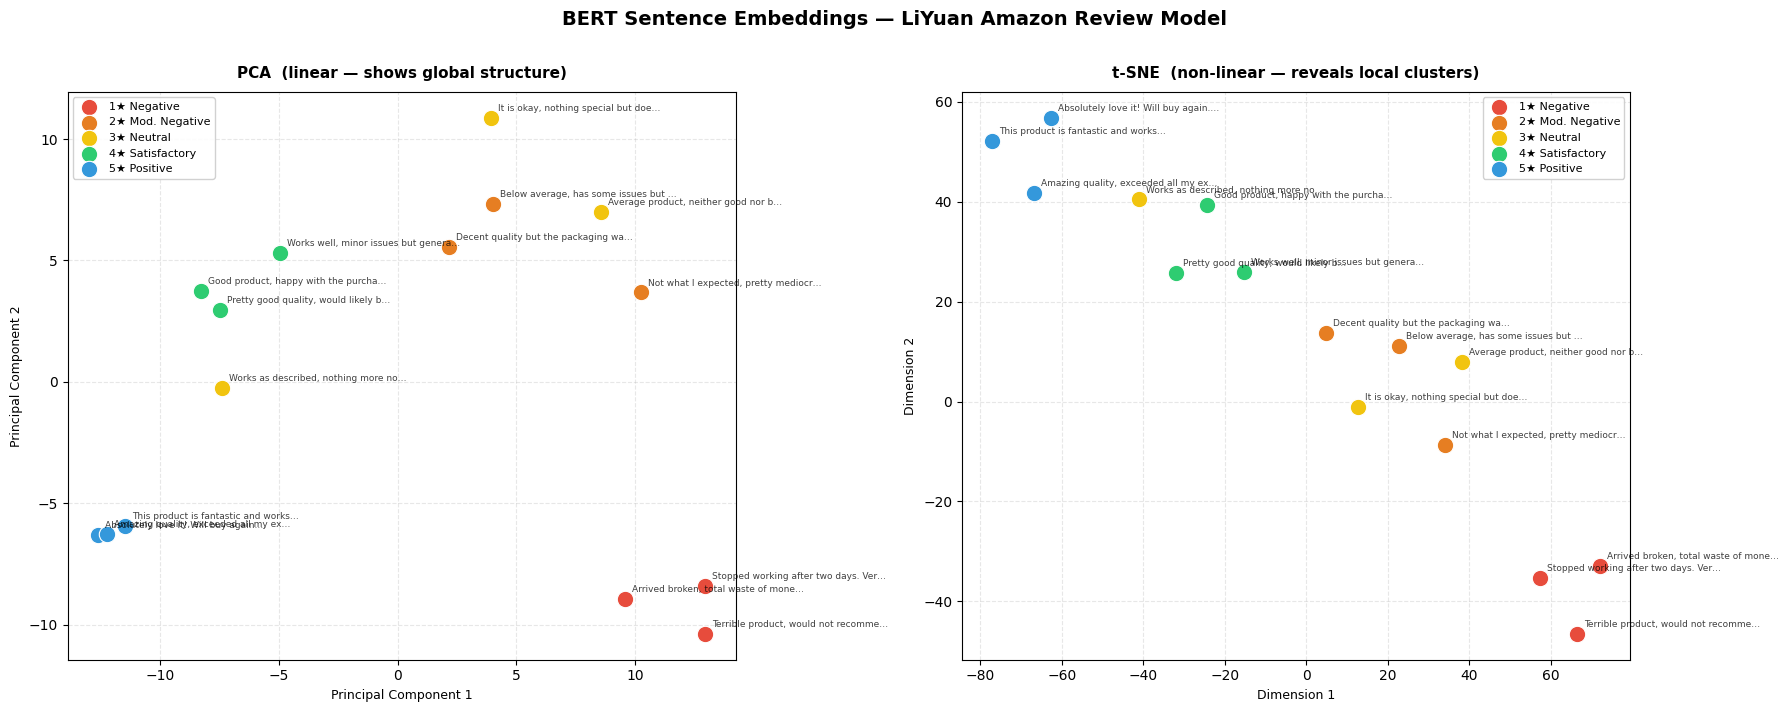

Plot saved to embeddings_visualization.png


In [1]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from transformers import AutoTokenizer, AutoModel
from sklearn.manifold import TSNE
from sklearn.decomposition import PCA

# Declare Finetuned Model
MODEL_NAME = "LiYuan/amazon-review-sentiment-analysis"
tokenizer  = AutoTokenizer.from_pretrained(MODEL_NAME)
model      = AutoModel.from_pretrained(MODEL_NAME)
model.eval()

# Test Sentences
sentences = [
    "Arrived broken, total waste of money",
    "Stopped working after two days. Very disappointed.",
    "Terrible product, would not recommend to anyone.",
    "Decent quality but the packaging was damaged",
    "Not what I expected, pretty mediocre overall.",
    "Below average, has some issues but not the worst.",
    "It is okay, nothing special but does the job",
    "Average product, neither good nor bad.",
    "Works as described, nothing more nothing less.",
    "Good product, happy with the purchase overall",
    "Works well, minor issues but generally satisfied.",
    "Pretty good quality, would likely buy again.",
    "This product is fantastic and works perfectly",
    "Absolutely love it! Will buy again.",
    "Amazing quality, exceeded all my expectations!",
]
# Rating Labels for Above Sentences
labels = [1,1,1, 2,2,2, 3,3,3, 4,4,4, 5,5,5]

# Extract [CLS] embeddings (Sentence level classification label) 
def get_embedding(text):
    inputs = tokenizer(text, return_tensors="pt", truncation=True, max_length=256)
    with torch.no_grad():
        outputs = model(**inputs)
    return outputs.last_hidden_state[:, 0, :].squeeze().numpy()  # [CLS] token

embeddings = np.array([get_embedding(s) for s in sentences])
print(f"Embeddings shape: {embeddings.shape}")  # (15, 768)

# Print full embedding vectors 
print("\n===== Full Embedding Vectors (768 dimensions each) =====\n")
for i, (sentence, embedding) in enumerate(zip(sentences, embeddings)):
    star = labels[i]
    print(f"[{star}★] {sentence}")
    print(f"  Shape : {embedding.shape}")
    print(f"  Min   : {embedding.min():.6f}")
    print(f"  Max   : {embedding.max():.6f}")
    print(f"  Mean  : {embedding.mean():.6f}")
    print(f"  Std   : {embedding.std():.6f}")
    print(f"  Vector:")
    for row_start in range(0, len(embedding), 8):
        row = embedding[row_start:row_start + 8]
        row_str = "  ".join(f"{val:8.4f}" for val in row)
        print(f"    [{row_start:03d}-{row_start + len(row) - 1:03d}]  {row_str}")
    print("-" * 80)

# Plot config
COLORS = {1:"#e74c3c", 2:"#e67e22", 3:"#f1c40f", 4:"#2ecc71", 5:"#3498db"}
NAMES  = {1:"1★ Negative", 2:"2★ Mod. Negative", 3:"3★ Neutral",
          4:"4★ Satisfactory", 5:"5★ Positive"}

fig, axes = plt.subplots(1, 2, figsize=(18, 7))
fig.suptitle("BERT Sentence Embeddings — LiYuan Amazon Review Model",
             fontsize=14, fontweight="bold", y=1.01)

def scatter_plot(ax, coords, title, xlabel, ylabel):
    for star in range(1, 6):
        idx = [i for i, l in enumerate(labels) if l == star]
        ax.scatter(coords[idx, 0], coords[idx, 1],
                   c=COLORS[star], label=NAMES[star],
                   s=140, edgecolors="white", linewidths=0.8, zorder=3)
    for i, sentence in enumerate(sentences):
        ax.annotate(sentence[:35] + "…",
                    (coords[i, 0], coords[i, 1]),
                    fontsize=6.5, alpha=0.75,
                    xytext=(5, 5), textcoords="offset points")
    ax.set_title(title, fontsize=11, fontweight="bold", pad=10)
    ax.set_xlabel(xlabel, fontsize=9)
    ax.set_ylabel(ylabel, fontsize=9)
    ax.legend(fontsize=8, framealpha=0.9)
    ax.grid(True, linestyle="--", alpha=0.3)

# PCA 
pca_2d = PCA(n_components=2).fit_transform(embeddings)
scatter_plot(axes[0], pca_2d,
             "PCA  (linear — shows global structure)",
             "Principal Component 1", "Principal Component 2")

# t-SNE 
tsne_2d = TSNE(n_components=2, perplexity=5, random_state=42, n_iter=1000).fit_transform(embeddings)
scatter_plot(axes[1], tsne_2d,
             "t-SNE  (non-linear — reveals local clusters)",
             "Dimension 1", "Dimension 2")

plt.tight_layout()
plt.savefig("embeddings_visualization.png", dpi=150, bbox_inches="tight")
plt.show()
print("Plot saved to embeddings_visualization.png")